In [13]:
!pip install pandas numpy seaborn matplotlib


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('/Super_store_dt(in) (1).csv')
df.shape

(9994, 21)

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [21]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [23]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

Creating the new columns


In [37]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Performing the EDA

In [27]:
total_sales = df['Sales'].sum()
print(total_sales)

2297201.07


In [28]:
total_profit = df['Profit'].sum()
print(total_profit)

286397.79000000004


In [29]:
df.groupby('Region')['Sales'].sum()

,Sales
Region,
Central,501239.88
East,678781.36
South,391721.90
West,725457.93


In [30]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18451.25
Office Supplies,122490.88
Technology,145455.66


In [40]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
April        137762.16
August       159043.99
December     325293.54
February      59751.26
January       94924.87
July         147238.11
June         152718.72
March        205005.51
May          155028.83
November     352461.09
October      200323.03
September    307649.96
Name: Sales, dtype: float64


In [41]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False)

,Profit
State,
California,76381.60
New York,74038.64
Washington,33402.70
Michigan,24463.15
Virginia,18598.00
Indiana,18382.97
Georgia,16250.08
Kentucky,11199.70
Minnesota,10823.22


Visualization using seaborn and matplotlib

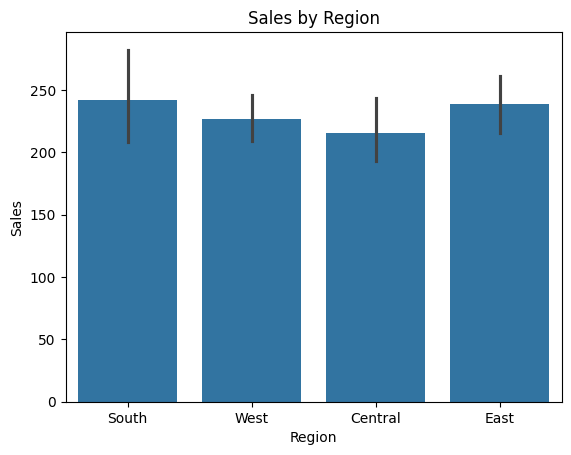

In [42]:
sns.barplot(x='Region', y='Sales', data=df)
plt.title("Sales by Region")
plt.show()

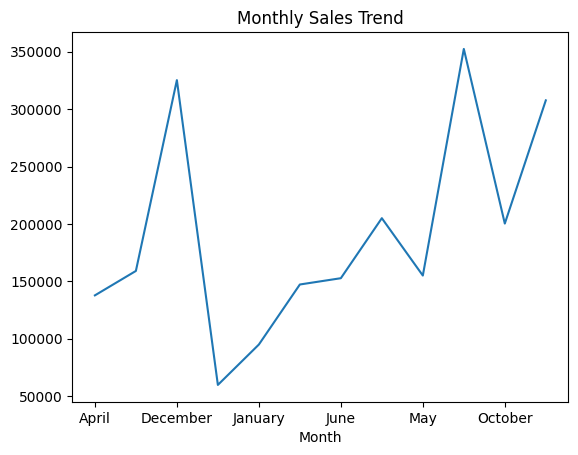

In [43]:
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

<Axes: xlabel='Category', ylabel='Profit'>

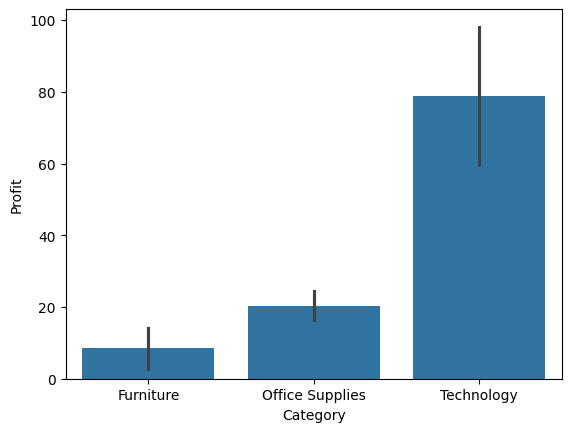

In [44]:
sns.barplot(x='Category', y='Profit', data=df)

<Axes: >

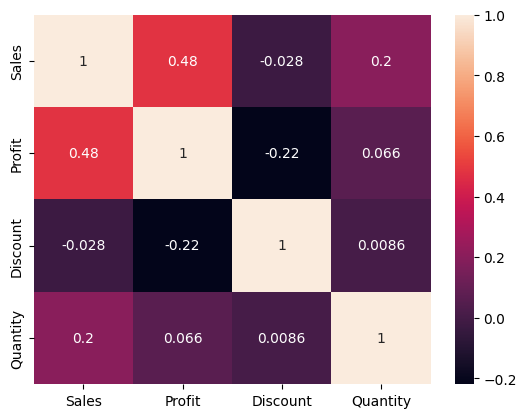

In [45]:
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)

In [46]:
df.to_csv("cleaned_superstore.csv", index=False)

In [47]:
from google.colab import files

df.to_csv("cleaned_superstore.csv", index=False)

files.download("cleaned_superstore.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>